In [8]:
!nvidia-smi

Wed Jun 24 15:26:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P0             30W /   70W |     647MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("pohs-workspace").project("segmentation-b9qi6-8fcvk")
version = project.version(1)
dataset = version.download("yolov8")

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO
import cv2
import glob
import os

model = YOLO("yolov8n-seg.pt")
dataset = "/content/segmentation-1"

model.train(
    data=f"{dataset}/data.yaml",
    epochs=20,
    imgsz=640
)

In [9]:
from ultralytics import YOLO
import cv2
import glob
import os

model = YOLO("/content/runs/segment/train-2/weights/best.pt")
dataset = "/content/segmentation-1"

image_paths = glob.glob(os.path.join(dataset, "test", "images", "*.jpg"))

for image_path in image_paths[:5]:
    image = cv2.imread(image_path)
    results = model(image)[0]

    print(image_path)


0: 640x640 2 surfaces, 9.2ms
Speed: 2.4ms preprocess, 9.2ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)
/content/segmentation-1/test/images/bed_74_jpg.rf.c273ca7960f2403773d71efb9e159517.jpg

0: 640x640 4 surfaces, 1 wall, 9.2ms
Speed: 3.1ms preprocess, 9.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
/content/segmentation-1/test/images/bed_73_jpg.rf.4ba5c3c79ca38cee705cee35329434d3.jpg

0: 640x640 3 surfaces, 9.2ms
Speed: 2.9ms preprocess, 9.2ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
/content/segmentation-1/test/images/bed_1161_jpg.rf.1764c06149b3c26915e8f288f598de72.jpg

0: 640x640 1 surface, 2 walls, 9.2ms
Speed: 2.5ms preprocess, 9.2ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
/content/segmentation-1/test/images/bed_1056_jpg.rf.3170fdec0f33c82ab1e0e0fc4893df60.jpg

0: 640x640 1 wall, 9.2ms
Speed: 2.1ms preprocess, 9.2ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
/conte

In [ ]:
!pip install supervision


0: 640x640 2 surfaces, 10.3ms
Speed: 2.9ms preprocess, 10.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


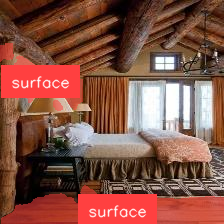


0: 640x640 4 surfaces, 1 wall, 10.9ms
Speed: 3.6ms preprocess, 10.9ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


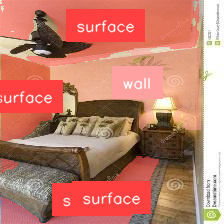


0: 640x640 3 surfaces, 11.6ms
Speed: 3.9ms preprocess, 11.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


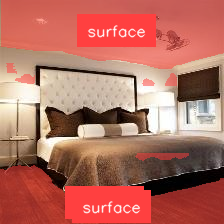


0: 640x640 1 surface, 2 walls, 9.5ms
Speed: 4.1ms preprocess, 9.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


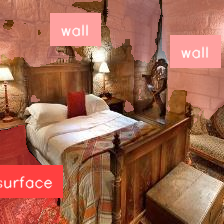


0: 640x640 1 wall, 15.7ms
Speed: 5.0ms preprocess, 15.7ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)


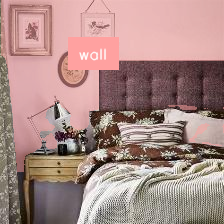

In [10]:
from google.colab.patches import cv2_imshow
import supervision as sv

mask_annotator = sv.MaskAnnotator()
label_annotator = sv.LabelAnnotator(text_position=sv.Position.CENTER_OF_MASS)

for image_path in image_paths[:5]:
    image = cv2.imread(image_path)

    results = model(image)[0]
    detections = sv.Detections.from_ultralytics(results)

    annotated_image = mask_annotator.annotate(
        scene=image.copy(),
        detections=detections,
    )

    annotated_image = label_annotator.annotate(
        scene=annotated_image,
        detections=detections,
    )
    cv2_imshow(annotated_image)